# 02 - Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import yaml
import os
import sys
sys.path.append('..')

from src.data.dataset import masks_to_polygons_dataset,split_dataset,clear_dataset_images
from src.data.yolo_export import convert_to_yolo_segmentation
from src.data.classifier_export import convert_to_classifier_crops
from src.utils.augmentation import apply_smart_aug
from src.classifier.class_balance import ClassDistributionPlanner

%matplotlib inline

In [2]:
images_path = '../data/raw/images'
masks_path  = '../data/raw/masks'
stage_1_path  = '../data/processed/Stage-1'
stage_2_path  = '../data/processed/Stage-2'

hair_images_path = '../data/raw/hair_overlay'

with open(os.path.join(stage_1_path,'data.yaml')) as f:
    s1_data_yaml = yaml.safe_load(f)

with open(os.path.join(stage_2_path,'data.yaml')) as f:
    s2_data_yaml = yaml.safe_load(f)

df = pd.read_csv('../data/raw/metadata.csv')

In [3]:
nv_df = df[df['dx'] == 'nv'].sample(3000,random_state=42)

nv_indices = [idx for idx in range(len(df)) if df.iloc[idx]['dx'] == 'nv']

# stage 2 excludes melanoma cases, so we filter them out before extracting polygons again
mel_indices = [idx for idx in range(len(df)) if df.iloc[idx]['dx'] == 'mel']

df_stage1 = df.drop(nv_indices)
df_stage2 = df.drop(nv_indices + mel_indices)

df_stage1 = pd.concat([df_stage1,nv_df])
df_stage2 = pd.concat([df_stage2,nv_df])

df_stage1.reset_index(drop=True,inplace=True)
df_stage2.reset_index(drop=True,inplace=True)

In [4]:
df_stage1 = masks_to_polygons_dataset(masks_path, df_stage1, 'dx', stage=1, epsilon_threshold=0.01)

df_stage1['dx'] = df_stage1['class_id'].apply(lambda x: 'mel' if x[0] else 'not_mel')
df_stage1.head()

  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Suc

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,not_mel,histo,[0],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,not_mel,histo,[0],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,not_mel,histo,[0],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,not_mel,histo,[0],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,not_mel,histo,[0],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [5]:
df_stage2 = masks_to_polygons_dataset(masks_path, df_stage2, 'dx', stage=2, epsilon_threshold=0.01)
df_stage2.head()

  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPoly

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,bkl,histo,[2],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,bkl,histo,[2],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,bkl,histo,[2],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,bkl,histo,[2],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,bkl,histo,[2],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [6]:
df_stage1['dx'].value_counts()

dx
not_mel    5197
mel        1113
Name: count, dtype: int64

In [7]:
df_stage2['dx'].value_counts()

dx
nv       3000
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [8]:
s1_train_df, s1_val_df , s1_test_df = split_dataset(df_stage1, 'dx', test_size=0.2, apply_leakage_check=True)


Train Patient ID : 3827
Val Patient ID   : 478
Test Patient ID  : 479

Train Images : 5057
Val Images   : 635
Test Images  : 618

Perfect! No Data Leakage Found.


In [9]:
s2_train_df, s2_val_df , s2_test_df = split_dataset(df_stage2, 'dx', test_size=0.2, apply_leakage_check=True)


Train Patient ID : 3336
Val Patient ID   : 417
Test Patient ID  : 417

Train Images : 4149
Val Images   : 517
Test Images  : 531

Perfect! No Data Leakage Found.


In [10]:
s1_train_df['dx'].value_counts()

dx
not_mel    4164
mel         893
Name: count, dtype: int64

In [11]:
s2_train_df['dx'].value_counts()

dx
nv       2399
bkl       870
bcc       411
akiec     264
vasc      115
df         90
Name: count, dtype: int64

In [12]:
s1_train_df.head()

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,not_mel,histo,[0],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,not_mel,histo,[0],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,not_mel,histo,[0],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,not_mel,histo,[0],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,not_mel,histo,[0],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [13]:
s2_train_df.head()

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,bkl,histo,[2],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,bkl,histo,[2],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,bkl,histo,[2],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,bkl,histo,[2],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,bkl,histo,[2],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [14]:
s1_train_df.to_pickle(os.path.join(stage_1_path,'train_df_splitted.pkl'))
s1_val_df.to_pickle(os.path.join(stage_1_path,'valid_df_splitted.pkl'))
s1_test_df.to_pickle(os.path.join(stage_1_path,'test_df_splitted.pkl'))

In [15]:
s2_train_df.to_pickle(os.path.join(stage_2_path,'train_df_splitted.pkl'))
s2_val_df.to_pickle(os.path.join(stage_2_path,'valid_df_splitted.pkl'))
s2_test_df.to_pickle(os.path.join(stage_2_path,'test_df_splitted.pkl'))

In [16]:
clear_dataset_images(s1_data_yaml,'all', confirm_prompt=False)
convert_to_yolo_segmentation(images_path,stage_1_path,s1_train_df,s1_val_df,s1_test_df)

Found 6310 files matching target='all'.


Deleting all images...: 100%|██████████| 6310/6310 [00:03<00:00, 2052.52it/s]


Deleted 6310 images. Failed: 0.


train Is Processing Now...: 100%|██████████| 5057/5057 [00:09<00:00, 515.18it/s]


train Done!


val Is Processing Now...: 100%|██████████| 635/635 [00:01<00:00, 493.96it/s]


val Done!


test Is Processing Now...: 100%|██████████| 618/618 [00:01<00:00, 513.04it/s]

test Done!


In [17]:
class_to_folder_diag_classifier = {'akiec': '01_AKIEC',
                                    'bcc': '02_BCC',
                                    'bkl': '03_BKL',
                                    'df': '04_DF',
                                    'nv': '05_NV',
                                    'vasc': '06_VASC'}

clear_dataset_images(s2_data_yaml,'all', confirm_prompt=False)
convert_to_classifier_crops(images_path,
                            stage_2_path,
                            class_to_folder_diag_classifier,
                            s2_train_df,s2_val_df,s2_test_df)

Found 5197 files matching target='all'.


Deleting all images...: 100%|██████████| 5197/5197 [00:01<00:00, 3777.90it/s]


Deleted 5197 images. Failed: 0.


test is processing now...: 100%|██████████| 531/531 [00:06<00:00, 85.66it/s] 


{'train': 4149, 'val': 517, 'test': 531}

In [39]:
DERM_AUG_CONFIG = {
    'hflip_p': 0.5,
    'vflip_p': 0.5,
    'rotate_limit': 20,
    'rotate_p': 0.5,
    'brightness_limit': 0.15,
    'contrast_limit': 0.15,
    'brightness_contrast_p': 0.4,
    'hue_shift_limit': 4,
    'sat_shift_limit': 10,
    'val_shift_limit': 4,
    'hue_sat_val_p': 0.4,
    'clahe_clip_limit': 2.0,
    'clahe_p': 0.3,
    'shift_limit': 0.05, 
    'scale_limit': 0.12,
    'shift_scale_rotate_p': 0.3,
    'hair_p': 0.2,
    'hair_overlay_path': hair_images_path
}


CLASSIFIER_AUG_CONFIG = {
    'hflip_p': 0.6,
    'vflip_p': 0.6,
    'rotate_limit': 20,
    'rotate_p': 0.6,
    'brightness_limit': 0.1,
    'contrast_limit': 0.2,
    'brightness_contrast_p': 0.4,
    'hue_shift_limit': 2,
    'sat_shift_limit': 5,
    'val_shift_limit': 2,
    'hue_sat_val_p': 0.3,
    'clahe_clip_limit': 1.5,
    'clahe_p': 0.3,
    'shift_limit': 0.1, 
    'scale_limit': 0.12,
    'shift_scale_rotate_p': 0.3,
    'hair_p': 0.18,
    'hair_overlay_path': hair_images_path,
}

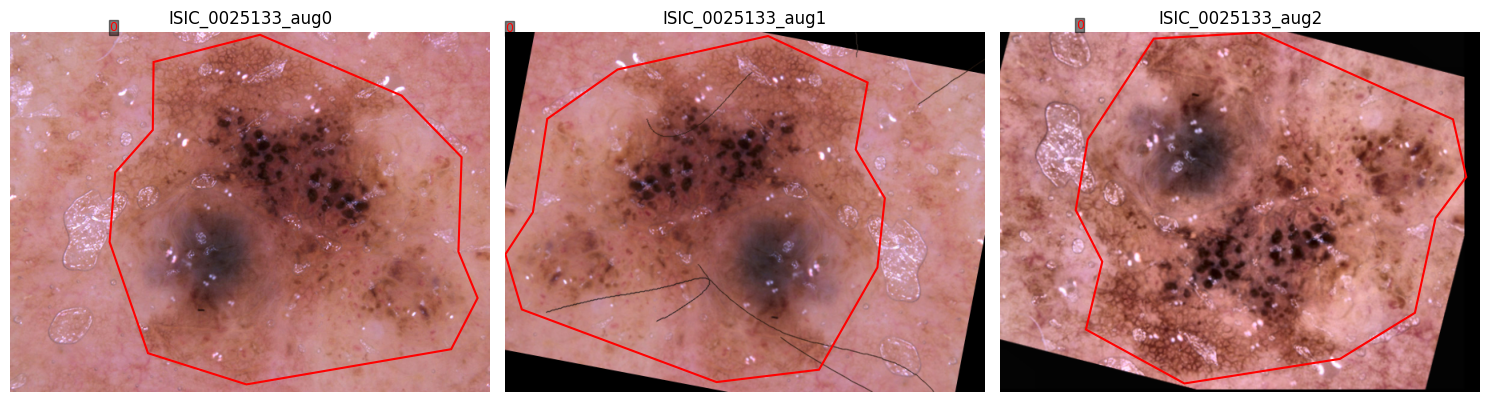

In [23]:
apply_smart_aug(s1_data_yaml,DERM_AUG_CONFIG,{},apply_debug=True)

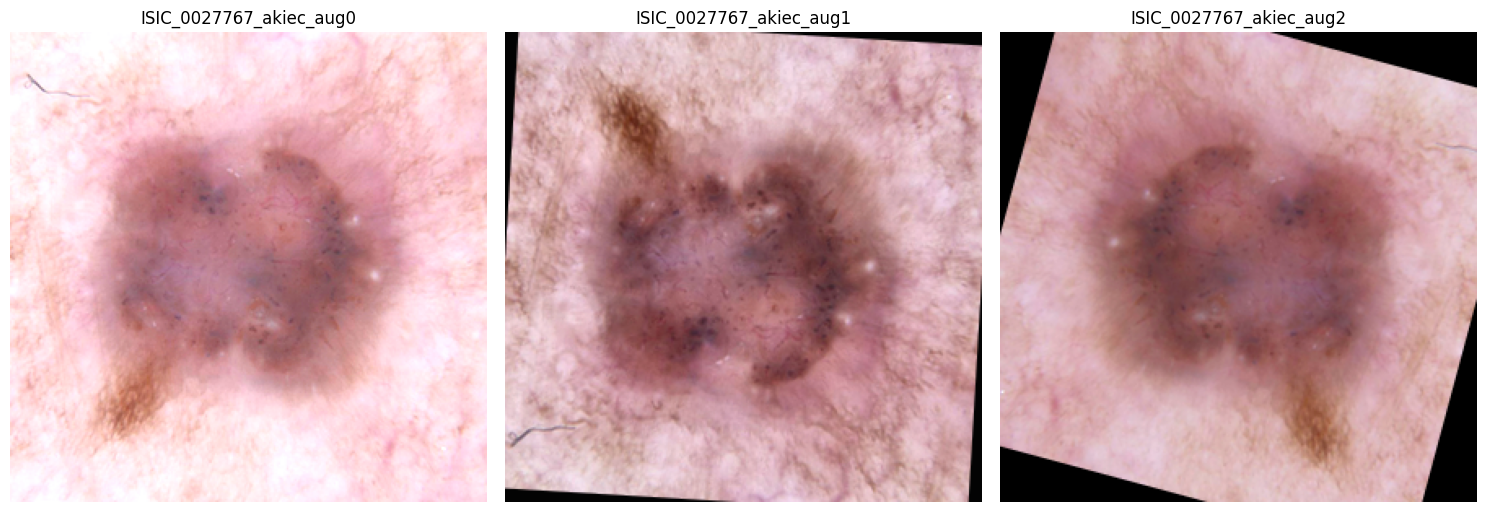

In [24]:
apply_smart_aug(s2_data_yaml,CLASSIFIER_AUG_CONFIG,{},dataset_type='classifier',apply_debug=True)

In [32]:
s1_planner = ClassDistributionPlanner.from_data_yaml(s1_data_yaml, dataset_type='segmentation')

print(s1_planner.summary())

print()

s1_plan = s1_planner.augmentation_plan()

print(s1_plan['current_counts'])
print(s1_plan['n_copies'])
print(s1_plan['projected_counts'])

Imbalance ratio (largest/smallest class): 4.7x
         0:   4175
         1:    893
Summary Showed Successfuly

{0: 4175, 1: 893}
{0: 0, 1: 1}
{0: 4175, 1: 1786}


In [38]:
s2_planner = ClassDistributionPlanner.from_data_yaml(s2_data_yaml, dataset_type='classifier')

print(s2_planner.summary())

print()

s2_plan = s2_planner.augmentation_plan(min_count=1200, max_count=2000)

print(s2_plan['current_counts'])
print(s2_plan['n_copies'])
print(s2_plan['projected_counts'])

Imbalance ratio (largest/smallest class): 26.7x
  01_AKIEC:    264
    02_BCC:    411
    03_BKL:    870
     04_DF:     90
     05_NV:   2399
   06_VASC:    115
Summary Showed Successfuly

{'01_AKIEC': 264, '02_BCC': 411, '03_BKL': 870, '04_DF': 90, '05_NV': 2399, '06_VASC': 115}
{'01_AKIEC': 4, '02_BCC': 2, '03_BKL': 1, '04_DF': 12, '05_NV': 0, '06_VASC': 9}
{'01_AKIEC': 1320, '02_BCC': 1233, '03_BKL': 1740, '04_DF': 1170, '05_NV': 2399, '06_VASC': 1150}


In [40]:
clear_dataset_images(s1_data_yaml, 'augmented', confirm_prompt=False)
apply_smart_aug(s1_data_yaml, DERM_AUG_CONFIG, n_copies_per_class=s1_plan['n_copies'])

No 'augmented' images found. Nothing to delete.


Augmenting Images Now...: 100%|██████████| 5057/5057 [01:22<00:00, 61.42it/s]


In [41]:
clear_dataset_images(s2_data_yaml, 'augmented', confirm_prompt=False)
apply_smart_aug(s2_data_yaml,CLASSIFIER_AUG_CONFIG, dataset_type='classifier',n_copies_per_class=s2_plan['n_copies'])

No 'augmented' images found. Nothing to delete.


Augmenting 06_VASC...: 100%|██████████| 115/115 [00:05<00:00, 20.76it/s]


In [42]:
s1_plan = s1_planner.augmentation_plan()

print(s1_plan['current_counts'])
print(s1_plan['n_copies'])
print(s1_plan['projected_counts'])

{0: 4175, 1: 893}
{0: 0, 1: 1}
{0: 4175, 1: 1786}


In [43]:
s2_plan = s2_planner.augmentation_plan(min_count=1200, max_count=2000)

print(s2_plan['current_counts'])
print(s2_plan['n_copies'])
print(s2_plan['projected_counts'])

{'01_AKIEC': 264, '02_BCC': 411, '03_BKL': 870, '04_DF': 90, '05_NV': 2399, '06_VASC': 115}
{'01_AKIEC': 4, '02_BCC': 2, '03_BKL': 1, '04_DF': 12, '05_NV': 0, '06_VASC': 9}
{'01_AKIEC': 1320, '02_BCC': 1233, '03_BKL': 1740, '04_DF': 1170, '05_NV': 2399, '06_VASC': 1150}
